In [7]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# Configuração de seeds para reprodutibilidade
np.random.seed(100)
torch.manual_seed(100)

# Carregamento do dataset
data = pd.read_csv('../data/classification2.csv', header=None)
X = data.iloc[:, :-1].values  
y = data.iloc[:, -1].values.reshape(-1, 1)

# Normalização (idêntica à sua implementação NumPy)
def normalize(X):
    return (X - np.min(X, axis=0)) / (np.max(X, axis=0) - np.min(X, axis=0))
X = normalize(X)

# Divisão treino/teste (75%/25%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [8]:
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.FloatTensor(y_train)
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.FloatTensor(y_test)

print("Formato dos tensores:")
print(f"X_train: {X_train_tensor.shape}, y_train: {y_train_tensor.shape}")
print(f"X_test: {X_test_tensor.shape}, y_test: {y_test_tensor.shape}")

Formato dos tensores:
X_train: torch.Size([88, 2]), y_train: torch.Size([88, 1])
X_test: torch.Size([30, 2]), y_test: torch.Size([30, 1])


In [9]:
class CustomNN(nn.Module):
    def __init__(self):
        super(CustomNN, self).__init__()
        # Arquitetura idêntica à sua: 2 → 3 → 2 → 1
        self.fc1 = nn.Linear(2, 3)
        self.fc2 = nn.Linear(3, 2)
        self.fc3 = nn.Linear(2, 1)
        self._initialize_weights()
    
    def _initialize_weights(self):
        # Inicialização idêntica à sua implementação NumPy
        for m in self.modules():
            if isinstance(m, nn.Linear):
                input_size = m.weight.size(1)
                limit = np.sqrt(6 / input_size)
                with torch.no_grad():
                    m.weight.uniform_(-limit, limit)
                    m.bias.zero_()
    
    def forward(self, x):
        # Sigmoid em todas as camadas como no seu código
        x = torch.sigmoid(self.fc1(x))
        x = torch.sigmoid(self.fc2(x))
        x = torch.sigmoid(self.fc3(x))
        return x

model = CustomNN()
print(model)

CustomNN(
  (fc1): Linear(in_features=2, out_features=3, bias=True)
  (fc2): Linear(in_features=3, out_features=2, bias=True)
  (fc3): Linear(in_features=2, out_features=1, bias=True)
)


In [10]:

learning_rate = 0.05  # Mesmo valor do seu código
epochs = 100000        # Mesmo número de épocas
criterion = nn.BCELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)  # SGD para equivaler ao seu GD

# Listas para armazenar métricas
losses = []
accuracies = []

In [11]:

for epoch in range(epochs):
    # Forward pass
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    
    # Backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    # Cálculo de acurácia
    predicted = (outputs > 0.5).float()
    accuracy = (predicted == y_train_tensor).float().mean()
    
    losses.append(loss.item())
    accuracies.append(accuracy.item())
    
    if epoch % 1000 == 0:
        print(f'Época {epoch:5d} | Loss: {loss.item():.4f} | Acurácia: {accuracy.item():.4f}')

Época     0 | Loss: 0.7153 | Acurácia: 0.4773
Época  1000 | Loss: 0.6916 | Acurácia: 0.5227
Época  2000 | Loss: 0.6911 | Acurácia: 0.5227
Época  3000 | Loss: 0.6905 | Acurácia: 0.5227
Época  4000 | Loss: 0.6898 | Acurácia: 0.5227
Época  5000 | Loss: 0.6889 | Acurácia: 0.5227
Época  6000 | Loss: 0.6880 | Acurácia: 0.5227
Época  7000 | Loss: 0.6868 | Acurácia: 0.4886
Época  8000 | Loss: 0.6853 | Acurácia: 0.4886
Época  9000 | Loss: 0.6836 | Acurácia: 0.5341
Época 10000 | Loss: 0.6817 | Acurácia: 0.5568
Época 11000 | Loss: 0.6795 | Acurácia: 0.5682
Época 12000 | Loss: 0.6773 | Acurácia: 0.6023
Época 13000 | Loss: 0.6752 | Acurácia: 0.6136
Época 14000 | Loss: 0.6734 | Acurácia: 0.5909
Época 15000 | Loss: 0.6718 | Acurácia: 0.6023
Época 16000 | Loss: 0.6703 | Acurácia: 0.6023
Época 17000 | Loss: 0.6691 | Acurácia: 0.5909
Época 18000 | Loss: 0.6680 | Acurácia: 0.5909
Época 19000 | Loss: 0.6669 | Acurácia: 0.5909
Época 20000 | Loss: 0.6659 | Acurácia: 0.5909
Época 21000 | Loss: 0.6650 | Acurá

In [ ]:

with torch.no_grad():
    # Avaliação no conjunto de teste
    test_outputs = model(X_test_tensor)
    test_predicted = (test_outputs > 0.5).float()
    test_accuracy = (test_predicted == y_test_tensor).float().mean()
    
    # Cálculo de métricas adicionais (como no seu código)
    y_test_np = y_test_tensor.numpy()
    pred_np = test_predicted.numpy()
    
    TP = np.sum((pred_np == 1) & (y_test_np == 1))
    TN = np.sum((pred_np == 0) & (y_test_np == 0))
    FP = np.sum((pred_np == 1) & (y_test_np == 0))
    FN = np.sum((pred_np == 0) & (y_test_np == 1))

print("\nMétricas Finais:")
print(f"Acurácia: {test_accuracy.item():.4f}")
print(f"Precisão: {TP / (TP + FP):.4f}" if (TP + FP) > 0 else "Precisão: 0.0")
print(f"Recall: {TP / (TP + FN):.4f}" if (TP + FN) > 0 else "Recall: 0.0")
print(f"F1-Score: {2 * TP / (2 * TP + FP + FN):.4f}" if (TP + FP + FN) > 0 else "F1-Score: 0.0")


Métricas Finais:
Acurácia: 0.8000
Precisão: 0.8125
Recall: 0.8125
F1-Score: 0.8125


In [12]:

import numpy as np

state = {
    'w1': model.fc1.weight.detach().numpy().T,  # Transposta para NumPy
    'b1': model.fc1.bias.detach().numpy().reshape(1, -1),
    'w2': model.fc2.weight.detach().numpy().T,
    'b2': model.fc2.bias.detach().numpy().reshape(1, -1),
    'w3': model.fc3.weight.detach().numpy().T,
    'b3': model.fc3.bias.detach().numpy().reshape(1, -1)
}

np.savez('../models/model_weights.npz', **state)
print("Pesos salvos em model_weights.npz")

Pesos salvos em model_weights.npz


In [13]:

with torch.no_grad():
    y_pred = model(X_test_tensor)
    y_pred_classes = (y_pred > 0.5).float().numpy()

y_true = y_test_tensor.numpy()

# Cálculo manual da matriz de confusão
TP = int(((y_pred_classes == 1) & (y_true == 1)).sum())
FP = int(((y_pred_classes == 1) & (y_true == 0)).sum())
FN = int(((y_pred_classes == 0) & (y_true == 1)).sum())
TN = int(((y_pred_classes == 0) & (y_true == 0)).sum())

# Cálculo das métricas
accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

# Exibição dos resultados
print("\nMÉTRICAS DE CLASSIFICAÇÃO:")
print(f"Acurácia: {accuracy:.4f} ({accuracy*100:.1f}%)")
print(f"Precisão: {precision:.4f}")
print(f"Recall (Sensibilidade): {recall:.4f}")
print(f"F1-Score: {f1_score:.4f}")
print("\nMATRIZ DE CONFUSÃO:")
print(f"Verdadeiros Positivos (TP): {TP}")
print(f"Falsos Positivos (FP): {FP}")
print(f"Falsos Negativos (FN): {FN}")
print(f"Verdadeiros Negativos (TN): {TN}")


MÉTRICAS DE CLASSIFICAÇÃO:
Acurácia: 0.8000 (80.0%)
Precisão: 0.8125
Recall (Sensibilidade): 0.8125
F1-Score: 0.8125

MATRIZ DE CONFUSÃO:
Verdadeiros Positivos (TP): 13
Falsos Positivos (FP): 3
Falsos Negativos (FN): 3
Verdadeiros Negativos (TN): 11


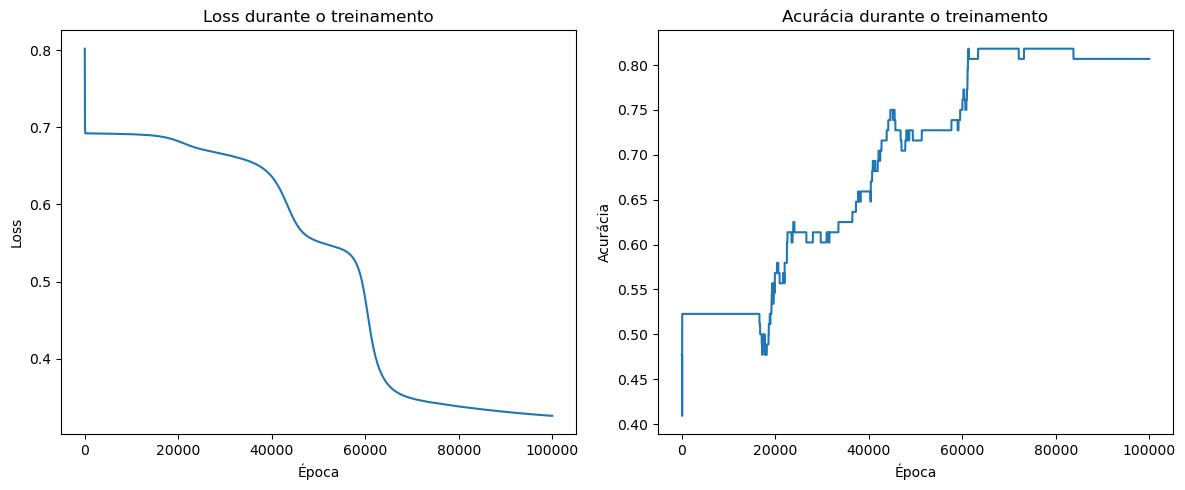

In [ ]:

import matplotlib.pyplot as plt
%matplotlib inline

# Gráfico de loss e acurácia
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(losses)
plt.title('Loss durante o treinamento')
plt.xlabel('Época')
plt.ylabel('Loss')

plt.subplot(1, 2, 2)
plt.plot(accuracies)
plt.title('Acurácia durante o treinamento')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.tight_layout()
plt.show()

In [14]:
import numpy as np

# Salvar os pesos em arquivos .npy
np.save('../models/pytorch_weights_layer0.npy', model.fc1.weight.detach().numpy().T)  # Transposta
np.save('../models/pytorch_weights_layer1.npy', model.fc2.weight.detach().numpy().T)
np.save('../models/pytorch_weights_layer2.npy', model.fc3.weight.detach().numpy().T)

np.save('../models/pytorch_bias_layer0.npy', model.fc1.bias.detach().numpy().reshape(1, -1))
np.save('../models/pytorch_bias_layer1.npy', model.fc2.bias.detach().numpy().reshape(1, -1))
np.save('../models/pytorch_bias_layer2.npy', model.fc3.bias.detach().numpy().reshape(1, -1))